In [33]:
from pynq import Overlay
from pynq import allocate
from math import log
import numpy as np
import matplotlib.pyplot as plt
import random
import wave

In [34]:
ol = Overlay('fft_block_design_wrapper.xsa')

In [35]:
ol?

In [36]:
data_dma = ol.fft_block.data_dma
config_dma = ol.fft_block.data_dma

In [37]:
data_send = data_dma.sendchannel
data_recv = data_dma.recvchannel
conf_send = config_dma.sendchannel

In [38]:
def dataConv(fft_direction,size):
    fft_direction.zfill(8) #fills emply spots w/ 0s
    
    byte2 = '0'*8 #all of byte 2 is zeros
    
    x = int(log(size,2))
    fft_size = bin(x)[2:]
    
    fft_size.zfill(8)
    totalData = fft_direction+byte2+fft_size
    return int(totalData,2)

In [39]:
Nsamples = 8192

In [40]:
interval = 1

def genData(Nsamples, interval):
    A1 = random.uniform(100,1000)
    A2 = random.uniform(100,1000)
    A3 = random.uniform(100,1000)
    f1 = random.uniform(100,150)
    f2 = random.uniform(200,300)
    f3 = random.uniform(500,600)
    w1 = 2*np.pi*f1
    w2 = 2*np.pi*f2
    w3 = 2*np.pi*f3
    
    t = np.linspace(0,interval,Nsamples)
    data = A1*np.sin(w1*t,dtype=np.csingle) + A2*np.sin(w2*t,dtype=np.csingle) + A3*np.sin(w3*t,dtype=np.csingle)
    return data,t

In [54]:
#wav files are 16 bit real
#allocate for input buffer expects np.csingle which is 64 bit complex (32 real 32 imag)

def wav_to_complex(filename, Nsamples, start_sec=5):
    wav = wave.open(filename, 'rb')

    fs = wav.getframerate()
    wav.setpos(fs * start_sec)  # skip silence at start

    frames = wav.readframes(Nsamples)

    audio = np.frombuffer(frames, dtype=np.int16)

    if wav.getnchannels() == 2:
        audio = audio[::2]

    audio_f32 = audio.astype(np.float32) / 32768.0
    complex_data = audio_f32.astype(np.csingle)

    return complex_data[:Nsamples]

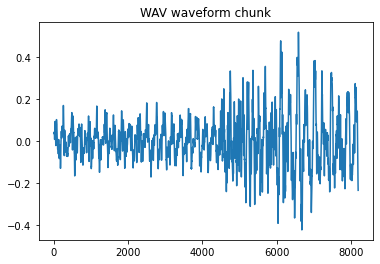

In [55]:
#FOR RANDOM GENERATED DATA

#data,t = genData(Nsamples,interval)
#plt.plot(t,np.real(data))

#FOR WAV DATA

data = wav_to_complex("Glimpse of a Memory.wav", Nsamples)

plt.plot(np.real(data))
plt.title("WAV waveform chunk")
plt.show()

In [56]:
%%time
output = np.fft.fft(data)

CPU times: user 11.2 ms, sys: 0 ns, total: 11.2 ms
Wall time: 8.79 ms


In [57]:
#freq = np.fft.fftfreq(Nsamples*interval,1/Nsamples)

freq = np.fft.fftfreq(Nsamples, 1/44100) #for wav file

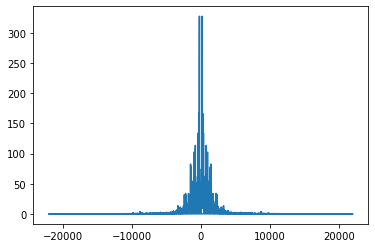

In [58]:
plt.plot(freq,np.abs(output))

In [59]:
#ALLOCATING BUFFER SIZE FOR DMA
#using csingle as fft block expects 64 bit complex values
input_buffer = allocate(Nsamples,np.csingle)
output_buffer = allocate(Nsamples,np.csingle)
np.copyto(input_buffer,data) #data send to input buffer (from genData)

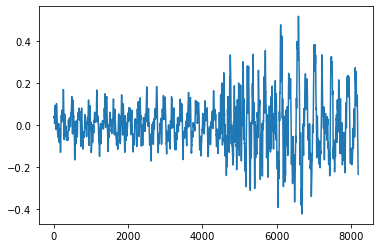

In [60]:
#verify input buffer holds same data
plt.plot(np.real(input_buffer))

In [61]:
%%time
data_send.transfer(input_buffer)
data_recv.transfer(output_buffer)
data_send.wait()
data_recv.wait()

CPU times: user 1.65 ms, sys: 77 µs, total: 1.72 ms
Wall time: 1.8 ms


In [62]:
output_buffer

PynqBuffer([5.653717 +0.j        , 5.2184486+0.08499146j,
            5.017708 +0.26187515j, ..., 4.93795  -0.3281746j ,
            5.0177116-0.26189804j, 5.2184525-0.08501053j], dtype=complex64)

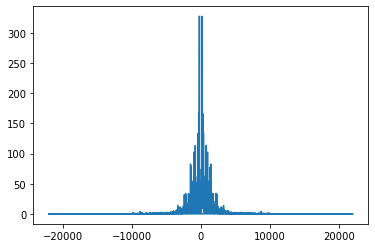

In [64]:
#verify fft performed correctly and output buffer holds data
plt.plot(freq,np.abs(output_buffer))